tensor([ 1.1158,  1.1161,  1.1161,  ..., 35.0640, 35.0644, 35.1164])
torch.Size([352, 640])
tensor([-1.0925e-01, -1.0923e-01, -1.0914e-01,  ...,  2.5446e+02,
         2.5462e+02,  2.5500e+02])


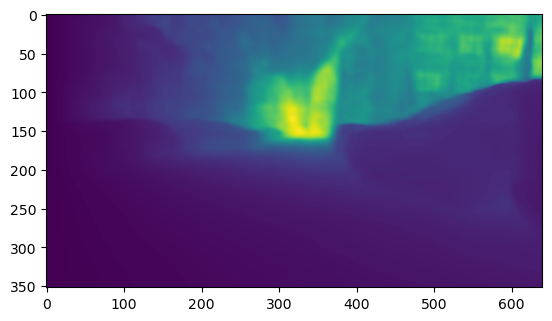

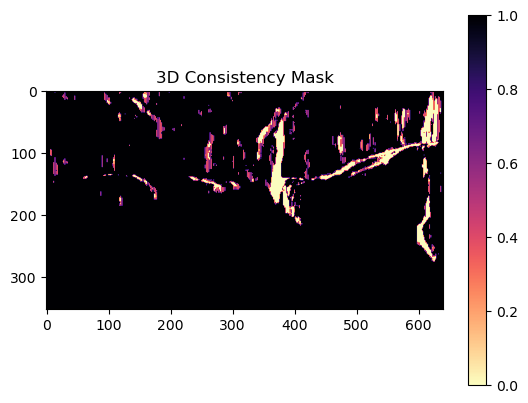

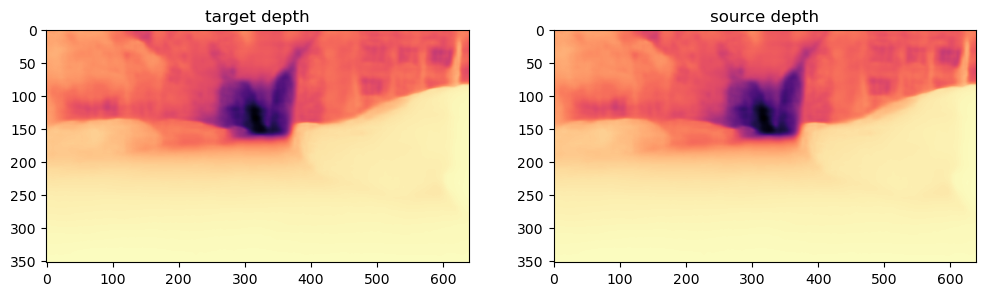

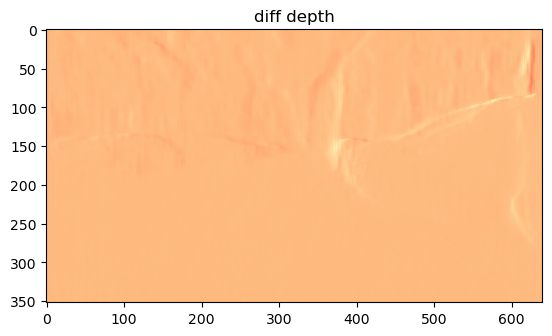

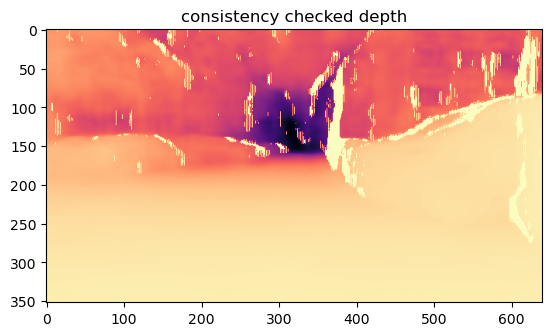

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

def backproject_depth_torch(depth, inv_K):
    B, _, H, W = depth.shape
    device = depth.device

    u = torch.arange(0, W, device=device)
    v = torch.arange(0, H, device=device)
    grid_u, grid_v = torch.meshgrid(u, v, indexing='xy')

    ones = torch.ones_like(grid_u)
    pix_coords = torch.stack([grid_u, grid_v, ones], dim=0).float()  # (3, H, W)
    pix_coords = pix_coords.reshape(3, -1).unsqueeze(0).repeat(B, 1, 1)  # (B, 3, H*W)

    cam_dirs = torch.bmm(inv_K, pix_coords)  # (B, 3, H*W)
    depth_flat = depth.view(B, 1, -1)

    cam_points = cam_dirs * depth_flat  # (B, 3, H*W)
    cam_points = cam_points.view(B, 3, H, W)
    return cam_points

def get_stereo_M_t2s_torch(baseline=0.12, device='cpu'):
    M = torch.eye(4, device=device).unsqueeze(0)
    M[:, 0, 3] = -baseline
    return M

def reproject_to_source_torch(cam_points, K, M_t2s):
    B, _, H, W = cam_points.shape
    device = cam_points.device

    cam_points_flat = cam_points.view(B, 3, -1)  # (B, 3, H*W)
    ones = torch.ones((B, 1, H * W), device=device)
    cam_points_homo = torch.cat([cam_points_flat, ones], dim=1)  # (B, 4, H*W)

    cam_points_src = torch.bmm(M_t2s, cam_points_homo)[:, :3, :]  # (B, 3, H*W)

    pixels = torch.bmm(K, cam_points_src)  # (B, 3, H*W)
    p0 = pixels[:, :2, :] / (pixels[:, 2:3, :] + 1e-8)  # (B, 2, H*W)
    p0 = p0.view(B, 2, H, W).permute(0, 2, 3, 1)  # (B, H, W, 2)
    return p0

def warp_depth_to_source_view(depth, K, inv_K, M_t2s):
    cam_points = backproject_depth_torch(depth, inv_K)
    p0 = reproject_to_source_torch(cam_points, K, M_t2s)

    B, _, H, W = depth.shape
    p0_norm = p0.clone()
    p0_norm[..., 0] = (p0[..., 0] / (W - 1)) * 2 - 1
    p0_norm[..., 1] = (p0[..., 1] / (H - 1)) * 2 - 1

    depth_warped = F.grid_sample(depth, p0_norm, mode='bilinear', align_corners=True)
    return depth_warped, cam_points, p0

# ----------------------
# Main 실행
# ----------------------
# Load left (target) depth
# depth_path = "/ssd1/jm_data/kitti_data/2011_10_03/2011_10_03_drive_0047_sync/image_02/data/0000001274.npy"
depth_path = "/ssd1/jm_data/depth/ssl/depth-hints/depth_vis/video/2025_05_08_drive_0007_sync/image_03/0000000465.npy"
depth_np = np.load(depth_path)
depth_tensor = torch.from_numpy(depth_np).unsqueeze(0).unsqueeze(0).float()  # (1,1,H,W)
print(torch.unique(depth_tensor))
H, W = depth_tensor.shape[-2:]
# Intrinsics
w,h = 640, 360
K = np.array([[260.8747863769531 / w, 0, 321.9953308105469 / w],
            [0, 260.8747863769531 / h, 179.68511962890625 / h],
            [0, 0, 1]], dtype=np.float32)

# zed2i

K_tensor = torch.from_numpy(K).unsqueeze(0).float()
inv_K_tensor = torch.inverse(K_tensor)

# 1. stereo 변환 행렬
M_t2s = get_stereo_M_t2s_torch(baseline=0.12, device=depth_tensor.device)
M_s2t = torch.inverse(M_t2s)

# 2. target → source로 depth warp
depth_warped_to_src, cam_points, p0 = warp_depth_to_source_view(depth_tensor, K_tensor, inv_K_tensor, M_t2s)
# 3. warped depth → source 3D 복원
cam_points_src = backproject_depth_torch(depth_warped_to_src, inv_K_tensor)

# 4. 다시 target 좌표계로 변환
cam_points_src_flat = cam_points_src.view(1, 3, -1)
ones = torch.ones((1, 1, H * W), device=depth_tensor.device)
cam_points_src_homo = torch.cat([cam_points_src_flat, ones], dim=1)
cam_points_src_to_target = torch.bmm(M_s2t, cam_points_src_homo)[:, :3, :].view(1, 3, H, W)

# 5. z difference 계산
z_diff = torch.abs(cam_points[0, 2] - cam_points_src_to_target[0, 2])
mask = (z_diff < 0.001).float()

print(cam_points[0, 2].shape)
cam_vis = cam_points[0, 0].cpu()
cam_vis_norm = cam_vis / cam_vis.max() * 255
print(torch.unique(cam_vis_norm))

plt.imshow(cam_vis_norm)
plt.axis("off")
plt.show()
# 시각화
plt.imshow(mask.cpu(), cmap='magma_r')
plt.title("3D Consistency Mask")
plt.colorbar()
plt.axis("off")
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.imshow(depth_np, cmap="magma_r")
plt.title("target depth")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(depth_warped_to_src.squeeze().squeeze().cpu(), cmap="magma_r")
plt.title("source depth")
plt.axis("off")
plt.show()

plt.imshow(depth_np - depth_warped_to_src.squeeze().squeeze().cpu().numpy(), cmap="magma_r")
plt.title("diff depth")
plt.axis("off")
plt.show()

plt.imshow(depth_np * mask.cpu().numpy(), cmap="magma_r")
plt.title("consistency checked depth")
plt.axis("off")
plt.show()


In [67]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# 설정
H, W = 4, 4
focal = 1.0
cx, cy = W / 2, H / 2

K = torch.tensor([[focal, 0, cx],
                  [0, focal, cy],
                  [0, 0, 1]], dtype=torch.float32)
inv_K = torch.inverse(K)

depth = torch.tensor([[1.0, 1.0, 1.0, 1.0],
                      [1.0, 1.0, 1.0, 1.0],
                      [1.0, 1.0, 2.0, 2.0],
                      [1.0, 1.0, 2.0, 2.0]], dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

# backproject
u = torch.arange(0, W)
v = torch.arange(0, H)
grid_u, grid_v = torch.meshgrid(u, v, indexing='xy')
pix_coords = torch.stack([grid_u, grid_v, torch.ones_like(grid_u)], dim=0).float().reshape(3, -1)
cam_dirs = inv_K @ pix_coords
cam_dirs = cam_dirs.reshape(1, 3, H, W)
cam_points = cam_dirs * depth

# baseline transform
baseline = 0.1
T = torch.eye(4)
T[0, 3] = -baseline
T_inv = torch.inverse(T)

cam_points_flat = cam_points.view(1, 3, -1)
ones = torch.ones((1, 1, H * W))
cam_points_h = torch.cat([cam_points_flat, ones], dim=1)
cam_points_src = (T @ cam_points_h)[..., :3, :].view(3, H, W)

# 투영
proj = (K @ cam_points_src.view(3, -1)).view(3, H, W)
x_proj = proj[0] / (proj[2] + 1e-8)
y_proj = proj[1] / (proj[2] + 1e-8)
grid = torch.stack([
    2 * (x_proj / (W - 1)) - 1,
    2 * (y_proj / (H - 1)) - 1
], dim=-1).unsqueeze(0)

# depth warp
warped_depth = F.grid_sample(depth, grid, mode='bilinear', align_corners=True)

# 다시 3D 복원 후 inverse transform
cam_dirs = cam_dirs  # 같은 것 다시 사용
cam_points_warped = cam_dirs * warped_depth
cam_points_warped_flat = cam_points_warped.view(1, 3, -1)
cam_points_warped_h = torch.cat([cam_points_warped_flat, ones], dim=1)
cam_points_returned = (T_inv @ cam_points_warped_h)[..., :3, :].view(1, 3, H, W)

# z 차이
z_diff = torch.abs(cam_points[0, 2] - cam_points_returned[0, 2])
print("Z-difference:\n", z_diff)


Z-difference:
 tensor([[0.1000, 0.0000, 0.0000, 0.0000],
        [0.1000, 0.0000, 0.0000, 0.0000],
        [0.1000, 0.0000, 0.0500, 0.0000],
        [0.1000, 0.0000, 0.0500, 0.0000]])
